In [1]:
# Libs
from time import gmtime, strftime
import xarray as xr
import numpy as np

# Locals
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
import oggm.cfg as cfg
from oggm.shop import gcm_climate

In [2]:
import xarray as xr

with xr.open_dataset('/home/usman/Music/GeeMap/Results/15_GCM_projections.nc') as ds:
    ds_merged = ds


In [3]:
ds_total_volume = ds_merged['volume'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          skipna=True,  # ignore nan values
                                          # important, we need values for every glacier (here 2) to do the sum
                                          # if some have NaN, the sum should also be NaN (if you don't set min_count, the sum will be 0, which is bad)
                                          min_count=len(ds_merged.rgi_id), 
                                          keep_attrs=True)  # keep the variable descriptions   


In [4]:
ds_total_volume_median = ds_total_volume.median(dim='GCM',  # over which dimension the median should be calculated
                                            skipna=True,  # ignore nan values
                                            keep_attrs=True)  # keep all variable descriptions
ds_total_volume_median

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27150141e+10, 2.26686245e+10, 2.25338757e+10,
        2.23617194e+10, 2.23566408e+10, 2.22924305e+10, 2.22660184e+10,
        2.21384624e+10, 2.20502167e+10, 2.19019284e+10, 2.18610951e+10,
        2.16353722e+10, 2.16373808e+10, 2.15175831e+10, 2.14760571e+10,
        2.13089542e+10, 2.11044693e+10, 2.10284080e+10, 2.09101952e+10,
        2.07321167e+10, 2.05362434e+10, 2.05137022e+10, 2.03108746e+10,
        2.02089792e+10, 2.01309598e+10, 2.00391732e+10, 2.01946458e+10,
        2.02408361e+10, 2.03158306e+10, 2.02068250e+10, 2.00190084e+10,
        1.97226721e+10, 1.96944160e+10, 1.96022976e+10, 1.94832389e+10,
        1.93446676e+10, 1.92023733e+10, 1.91152482e+10, 1.91080078e+10,
        1.90095092e+10, 1.90236248e+10, 1.89431588e+10, 1.88439665e+10,
        1.87293044e+10, 1.86095325e+10, 1.84098128e+10, 1.84074420e+10,
        1.82604545e+10, 1.82895243e+10, 1.82053050e+10, 1.81267116e+10,
        1.80981415e+10, 1.82155327e+10, 1.81820435e+10, 1.81664629e+10,
        1.80807873e+10, 1.79438090e+10, 1.78778159e+10, 1.77806044e+10,
        1.77396332e+10, 1.76311381e+10, 1.74877177e+10, 1.73951726e+10,
        1.72303782e+10, 1.70799189e+10, 1.70663034e+10, 1.69266586e+10,
        1.67894799e+10, 1.69294352e+10, 1.67901567e+10, 1.65754277e+10,
        1.64249583e+10, 1.63727511e+10, 1.63811758e+10, 1.63769619e+10,
        1.64652927e+10, 1.61107552e+10, 1.60072037e+10, 1.58399736e+10,
...
        2.22523229e+10, 2.21283267e+10, 2.19568598e+10, 2.16595540e+10,
        2.14879820e+10, 2.13077212e+10, 2.11757775e+10, 2.10189423e+10,
        2.11720642e+10, 2.11043163e+10, 2.09669246e+10, 2.08112965e+10,
        2.06721806e+10, 2.03549722e+10, 2.01171706e+10, 1.99963147e+10,
        1.96656883e+10, 1.95535316e+10, 1.94013015e+10, 1.93053006e+10,
        1.92557914e+10, 1.92607748e+10, 1.91001405e+10, 1.89278820e+10,
        1.87947006e+10, 1.87084015e+10, 1.84378390e+10, 1.83185485e+10,
        1.82363948e+10, 1.81151340e+10, 1.77710343e+10, 1.77558465e+10,
        1.74905538e+10, 1.73028158e+10, 1.71552737e+10, 1.71212158e+10,
        1.69275116e+10, 1.65659961e+10, 1.62437543e+10, 1.62127958e+10,
        1.59893140e+10, 1.56971111e+10, 1.56957915e+10, 1.55860289e+10,
        1.53860893e+10, 1.50953705e+10, 1.50317449e+10, 1.49879141e+10,
        1.46745848e+10, 1.45723330e+10, 1.45747663e+10, 1.45502259e+10,
        1.42639423e+10, 1.39323119e+10, 1.36601804e+10, 1.35252204e+10,
        1.32025095e+10, 1.28689885e+10, 1.26664024e+10, 1.25802065e+10,
        1.24082067e+10, 1.20605901e+10, 1.19419339e+10, 1.15701908e+10,
        1.13261390e+10, 1.09301309e+10, 1.06811972e+10, 1.04090696e+10,
        1.02597796e+10, 1.00456298e+10, 9.77191357e+09, 9.39096230e+09,
        9.12911620e+09, 8.88703693e+09, 8.58996513e+09, 8.49669327e+09,
        8.33448628e+09, 8.04901609e+09, 7.76032326e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [5]:
import matplotlib.pyplot as plt

In [6]:
# estimate the minimum volume for each time step and scenario over the GCMs
ds_total_volume_min = ds_total_volume.min(dim='GCM', keep_attrs=True,skipna=True)
# estimate the 25th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p25 = ds_total_volume.quantile(0.25, dim='GCM', keep_attrs=True,skipna=True)
# estimate the 50th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p50 = ds_total_volume.quantile(0.5, dim='GCM', keep_attrs=True,skipna=True)
# this is the same as the median -> Let's check
np.testing.assert_allclose(ds_total_volume_median,ds_total_volume_p50)
# estimate the 75th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p75 = ds_total_volume.quantile(0.75, dim='GCM', keep_attrs=True,skipna=True)
# estimate the maximum volume for each time step and scenario over the GCMs
ds_total_volume_max = ds_total_volume.max(dim='GCM', keep_attrs=True,skipna=True)

# Think twice if it is appropriate to compute a mean/std over your GCM sample, is it Gaussian distributed?
# Otherwise use instead median and percentiles or total range
ds_total_volume_mean = ds_total_volume.mean(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_std = ds_total_volume.std(dim='GCM', keep_attrs=True,
                                            skipna=True)

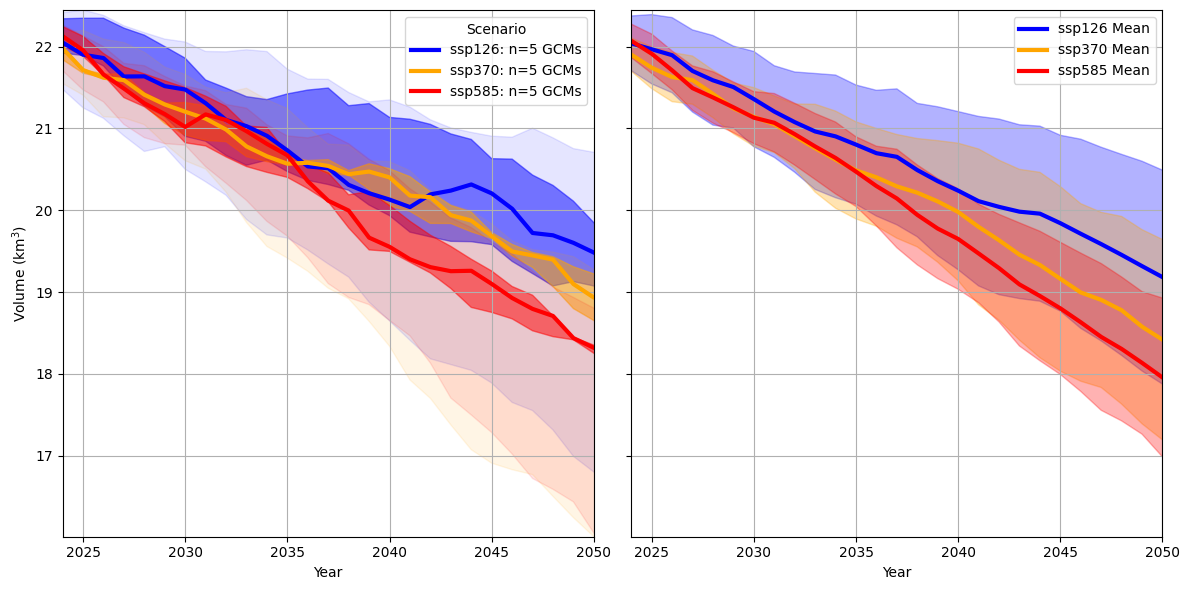

In [8]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1)

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario])

# Set precise axis limits for the projection period 2024–2050
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2024, 2050])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2024, 2050)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2024, 2050)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2024, 2050)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2024, 2050)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario', loc='upper right')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(loc='upper right')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_2024_2050_fitted.png', dpi=500, bbox_inches='tight')
plt.show()


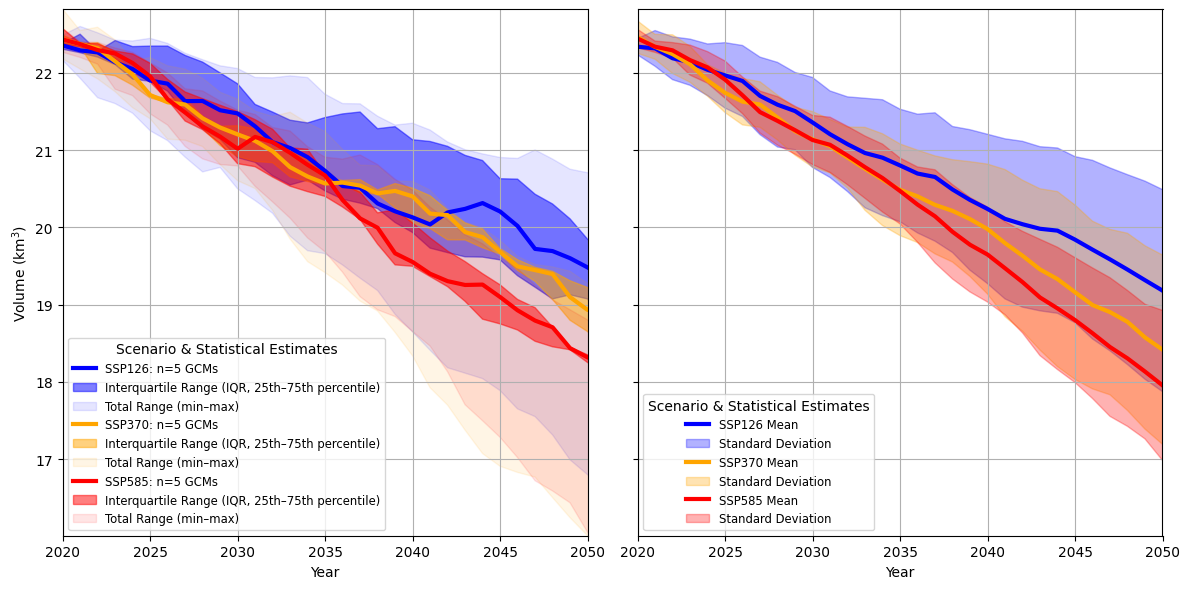

In [9]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario.upper()}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile Range (IQR, 25th–75th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='Total Range (min–max)')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario.upper()} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario],
                        label='Standard Deviation')

# Set precise axis limits for the projection period 2024–2050
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2020, 2050])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2020, 2050)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2050)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2020, 2050)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2050)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_2020_2050_fitted_001.png', dpi=500, bbox_inches='tight')
plt.show()


In [13]:
import pandas as pd

# Convert xarray datasets into pandas DataFrames
df_median = ds_total_volume_median.to_dataframe('median_volume_m3').reset_index()
df_mean = ds_total_volume_mean.to_dataframe('mean_volume_m3').reset_index()
df_min = ds_total_volume_min.to_dataframe('min_volume_m3').reset_index()
df_max = ds_total_volume_max.to_dataframe('max_volume_m3').reset_index()
df_p25 = ds_total_volume_p25.to_dataframe('p25_volume_m3').reset_index()
df_p75 = ds_total_volume_p75.to_dataframe('p75_volume_m3').reset_index()
df_std = ds_total_volume_std.to_dataframe('std_volume_m3').reset_index()

# Merge DataFrames on correct keys, avoiding duplicate columns
merge_keys = ['time', 'SCENARIO']  # Adjust keys if needed

# Drop duplicate or unnecessary columns before merging
df_median = df_median.loc[:, ~df_median.columns.duplicated()]
df_mean = df_mean.loc[:, ~df_mean.columns.duplicated()]
df_min = df_min.loc[:, ~df_min.columns.duplicated()]
df_max = df_max.loc[:, ~df_max.columns.duplicated()]
df_p25 = df_p25.loc[:, ~df_p25.columns.duplicated()]
df_p75 = df_p75.loc[:, ~df_p75.columns.duplicated()]
df_std = df_std.loc[:, ~df_std.columns.duplicated()]

# Start merging
df_combined = pd.merge(df_median, df_mean, on=merge_keys, how='outer', suffixes=('', '_mean'))
df_combined = pd.merge(df_combined, df_min, on=merge_keys, how='outer', suffixes=('', '_min'))
df_combined = pd.merge(df_combined, df_max, on=merge_keys, how='outer', suffixes=('', '_max'))
df_combined = pd.merge(df_combined, df_p25, on=merge_keys, how='outer', suffixes=('', '_p25'))
df_combined = pd.merge(df_combined, df_p75, on=merge_keys, how='outer', suffixes=('', '_p75'))
df_combined = pd.merge(df_combined, df_std, on=merge_keys, how='outer', suffixes=('', '_std'))

# Save the combined DataFrame to an Excel file
excel_output_path = '/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_data_2020_2050.xlsx'
df_combined.to_excel(excel_output_path, index=False)

# Print Excel save confirmation
print(f"Final data saved to: {excel_output_path}")


Final data saved to: /home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_data_2020_2050.xlsx


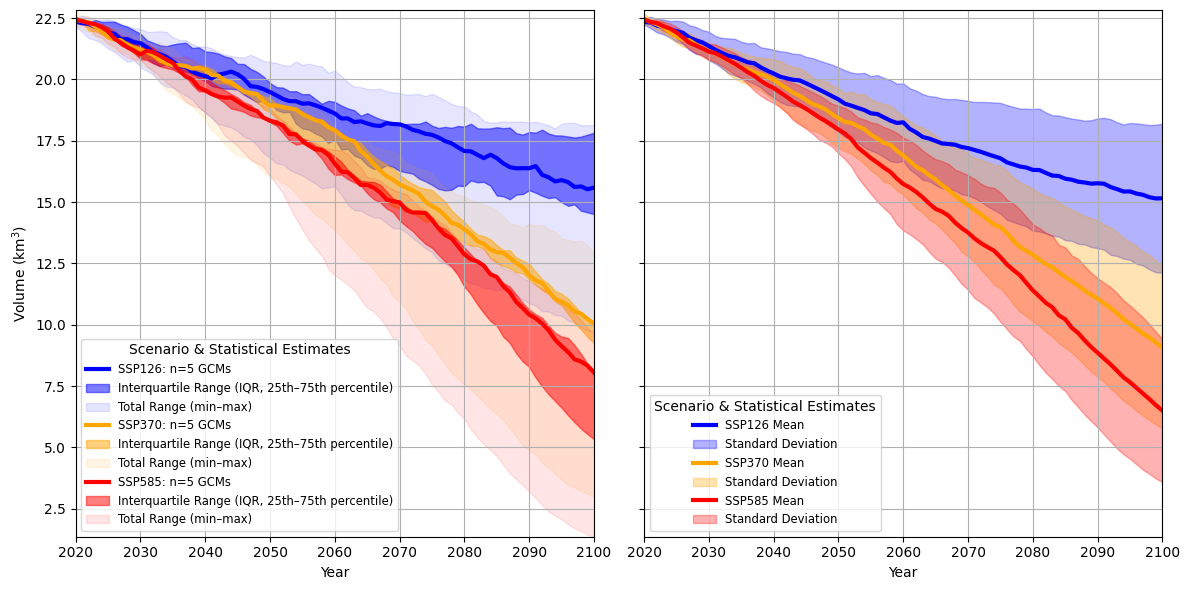

In [14]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario.upper()}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile Range (IQR, 25th–75th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='Total Range (min–max)')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario.upper()} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario],
                        label='Standard Deviation')

# Set precise axis limits for the projection period 2024–2050
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2020, 2100])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2020, 2100)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2050)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2020, 2100)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2100)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_2020_2100_fitted_001.png', dpi=500, bbox_inches='tight')
plt.show()


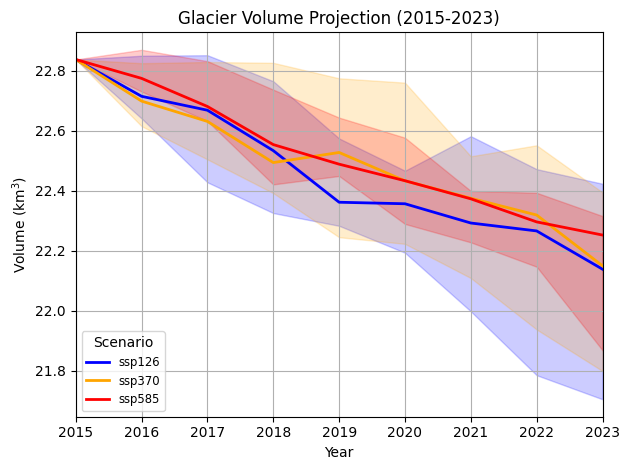

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2015_2023.png


In [35]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2015) & (pd_total_volume['time'] <= 2023)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2015-2023)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2015, 2023)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2015_2023.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


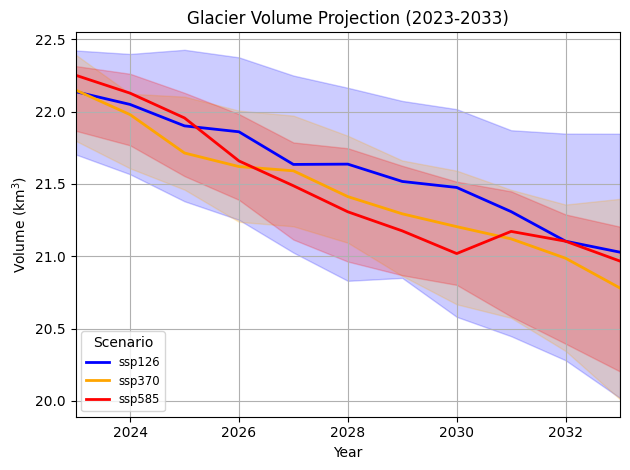

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2023_2033.png


In [36]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2023) & (pd_total_volume['time'] <= 2033)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2023-2033)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2023, 2033)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2023_2033.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


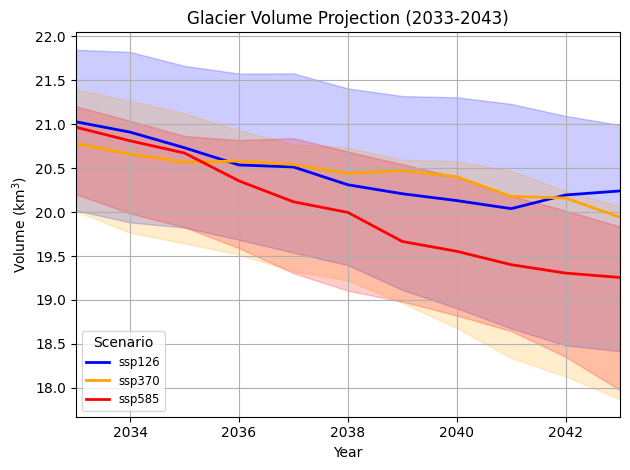

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2033_2043.png


In [37]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2033) & (pd_total_volume['time'] <= 2043)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2033-2043)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2033, 2043)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2033_2043.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


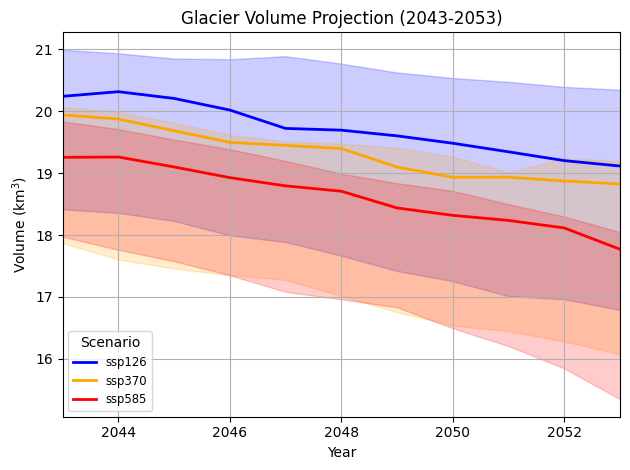

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2043_2053.png


In [38]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2043) & (pd_total_volume['time'] <= 2053)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2043-2053)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2043, 2053)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2043_2053.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


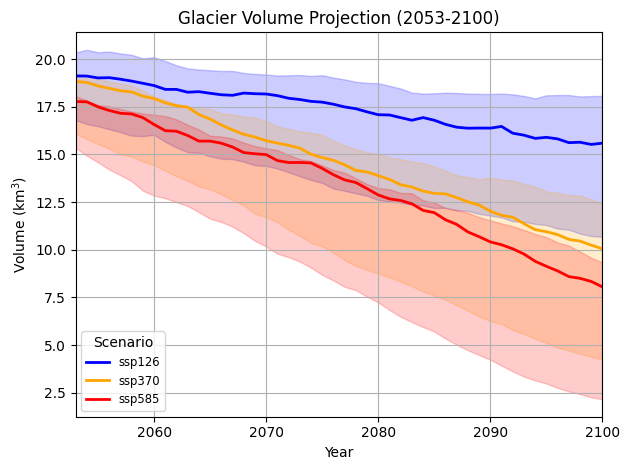

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2053_2100.png


In [39]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2053) & (pd_total_volume['time'] <= 2100)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2053-2100)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2053, 2100)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2053_2100.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


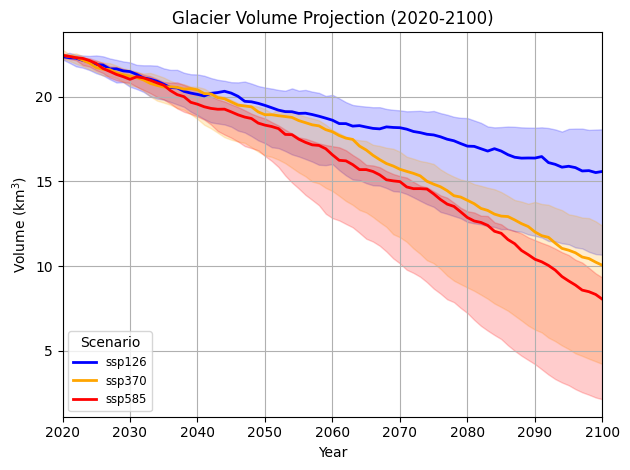

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Glacier_2020_2100.png


In [49]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2100
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2020) & (pd_total_volume['time'] <= 2100)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels, title, and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projection (2020-2100)')
plt.grid(True)

# Adjust legend location
plt.legend(title='Scenario', loc='lower left', bbox_to_anchor=(0, 0), fontsize='small')

# Set x-axis limits to tightly fit the range
plt.xlim(2020, 2100)

# Adjust layout to avoid clipping
plt.tight_layout()

# Save the graph
output_path = '/home/usman/Music/GeeMap/Results/Volume/Glacier_2020_2100.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')

# Display the graph
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


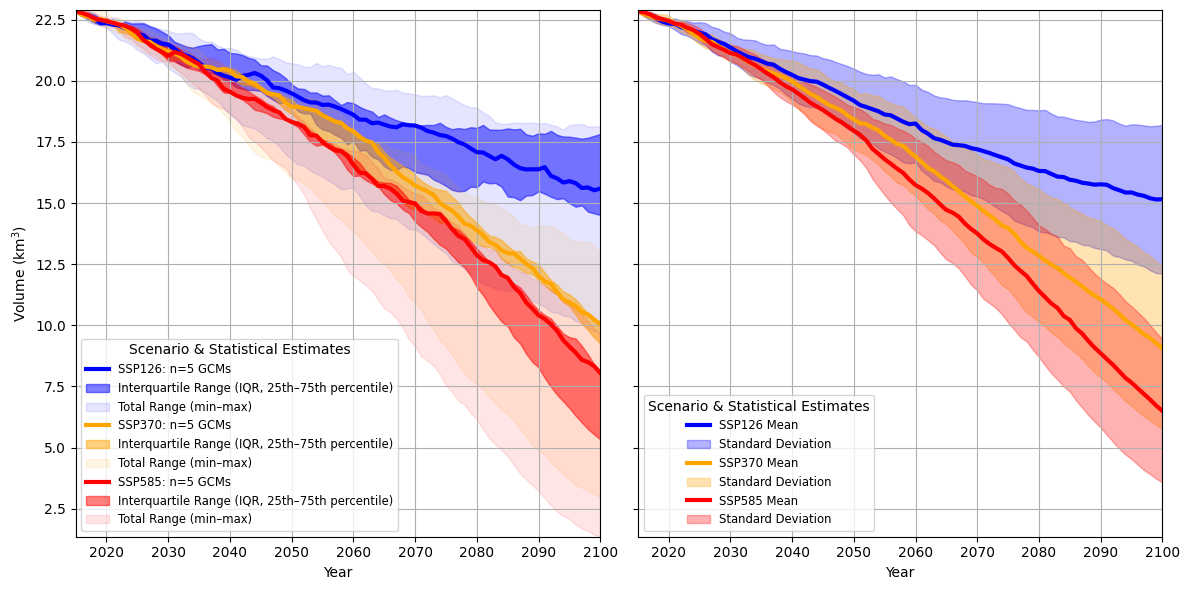

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Mean_GCM_2015_2100.png


In [43]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario.upper()}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile Range (IQR, 25th–75th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='Total Range (min–max)')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario.upper()} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario],
                        label='Standard Deviation')

# Set precise axis limits for the projection period 2015–2100
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2015, 2100])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2015, 2100)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2015, 2100)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2015, 2100)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2015, 2100)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
output_path = '/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_2015_2100.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")


In [44]:
print(ds_total_volume_median.time.values)


[2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025. 2026.
 2027. 2028. 2029. 2030. 2031. 2032. 2033. 2034. 2035. 2036. 2037. 2038.
 2039. 2040. 2041. 2042. 2043. 2044. 2045. 2046. 2047. 2048. 2049. 2050.
 2051. 2052. 2053. 2054. 2055. 2056. 2057. 2058. 2059. 2060. 2061. 2062.
 2063. 2064. 2065. 2066. 2067. 2068. 2069. 2070. 2071. 2072. 2073. 2074.
 2075. 2076. 2077. 2078. 2079. 2080. 2081. 2082. 2083. 2084. 2085. 2086.
 2087. 2088. 2089. 2090. 2091. 2092. 2093. 2094. 2095. 2096. 2097. 2098.
 2099. 2100. 2101.]


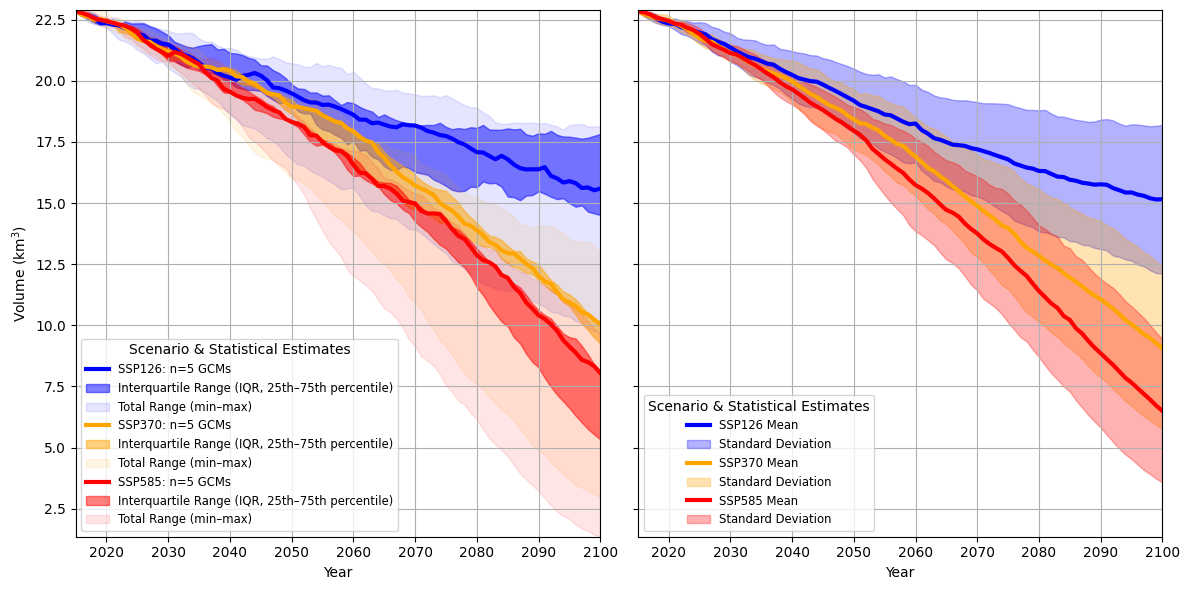

Graph saved to: /home/usman/Music/GeeMap/Results/Volume/Mean_GCM_2015_2100_adjusted.png


In [46]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario.upper()}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile Range (IQR, 25th–75th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='Total Range (min–max)')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario.upper()} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario],
                        label='Standard Deviation')

# Set precise axis limits for the projection period 2015–2100
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2015, 2100])

    # Dynamically calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2015, 2100)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2015, 2100)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2015, 2100)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2015, 2100)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
output_path = '/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_2015_2100_adjusted.png'
plt.savefig(output_path, dpi=500, bbox_inches='tight')
plt.show()

# Confirm save
print(f"Graph saved to: {output_path}")
